In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Sentiment Analysis of Foreign Affairs Texts

## Overview

This notebook applies the sentiment analysis pipeline to the manifesto sentences previously identified as belonging to the **Foreign Affairs** policy dimension.

The topic analysis notebook produces an intermediate corpus containing manifesto text classified as relevant to Foreign Affairs. This notebook takes that corpus as input and estimates the sentiment expressed towards countries mentioned in the corresponding text.

The analysis is performed separately for the **United States** and **Australia**.

### Analytical pipeline

The complete workflow is:

```text
Foreign Affairs manifesto sentences
              │
              ▼
      Sentiment analysis
              │
              ▼
Sentiment score for each text segment
              │
              ▼
       Country detection
              │
              ▼
Sentiment associated with each country
              │
              ▼
Aggregation by party / election / country
              │
              ▼
       Visualisation
```

The resulting country-level scores can then be used to study how political parties express positive or negative sentiment towards specific countries in their Foreign Affairs discourse.

In [2]:
import pandas as pd
import spacy
from sentiment_analysis import sentiment_analysis as sa
from sentiment_analysis.country_aliases_generation import generate_wikidata_country_dictionary

# Global sentiment analysis

## 3. Global configuration

The sentiment pipeline relies on the English spaCy model.

A dictionary of country aliases is also generated. This dictionary is used to recognise references to countries even when they do not appear under a single canonical name.

For example, a country can potentially be mentioned using different forms, abbreviations or alternative names. Mapping these aliases to a common country identifier makes it possible to aggregate sentiment consistently.

The sentiment analyser is then initialised using both the spaCy model and the country dictionary.

At this stage, the NLP components required by the rest of the pipeline are ready.

In [3]:
NLP = spacy.load("en_core_web_sm")
COUNTRY_SYNONYMS_DICT = generate_wikidata_country_dictionary()

sentiment_analyzer = sa.setup_sentiment_analyzer(
    nlp=NLP, 
    country_synonyms_dict=COUNTRY_SYNONYMS_DICT
)

Connexion à Wikidata...


# 2. USA manifesto analysis

The first step loads the `Foreign_Affairs` corpus extracted during the topic-analysis stage.

The sentiment score is then computed for the texts in the corpus. This produces the sentiment information required for the subsequent country-level analysis.

The overall sentiment distribution can be visualized to inspect the results before focusing on individual countries.

In [4]:
usa_foreignAffairs = pd.read_csv("../data/intermediate/foreign_affairs/usa_foreignAffairs_text.csv", index_col=0)
usa_foreignAffairs = sa.compute_sentiment(usa_foreignAffairs)

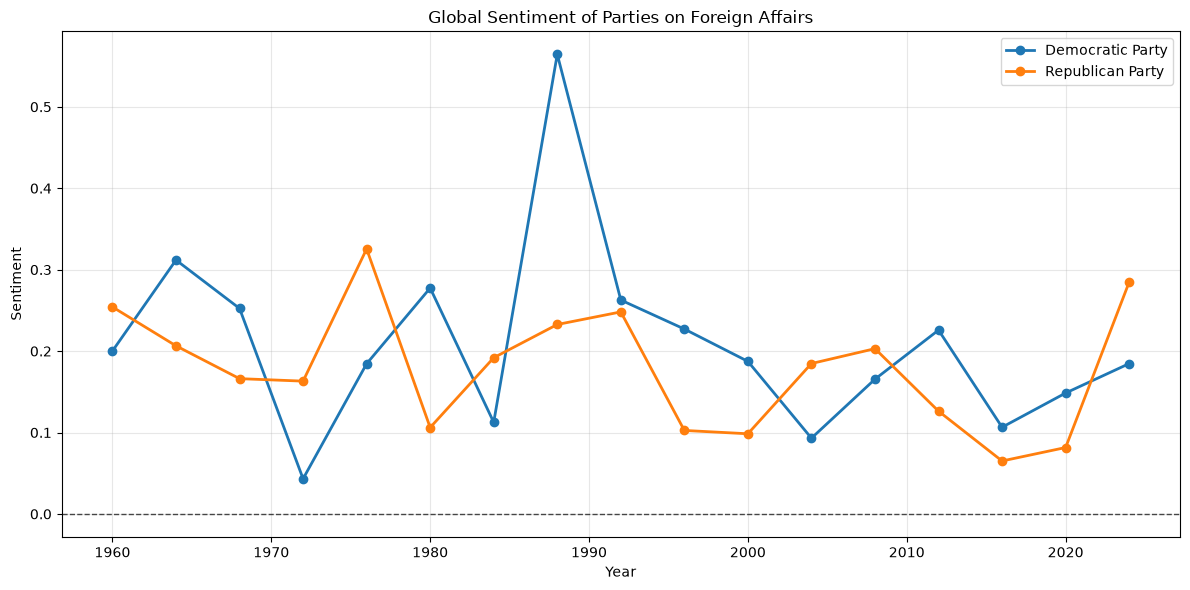

In [5]:
sa.plot_sentiment(usa_foreignAffairs)

In [6]:
foreignAffairs_usa = sa.compute_country_scores(
    section_dataframe=usa_foreignAffairs, 
    nlp=NLP, 
    analyzer=sentiment_analyzer, 
    country_synonyms_dict=COUNTRY_SYNONYMS_DICT
)

In [7]:
foreignAffairs_usa

,year,text,party,sentiment,sentiment_by_countries,number_mentions
0,1960,They have admitted that the Soviet Union leads...,Democratic Party,0.200130,"{'CUBA': -0.0258, 'ISRAEL': 0.60195, 'UNITED_S...","{'CUBA': 1, 'ISRAEL': 2, 'UNITED_STATES': 9}"
1,1964,"In 1960, freedom was on the defensive. The Com...",Democratic Party,0.311839,"{'ALBANIA': 0.9081, 'BULGARIA': 0.9081, 'CENTR...","{'ALBANIA': 1, 'BULGARIA': 1, 'CENTRAL_AFRICAN..."
2,1968,THE WORLD The conscience of the entire world h...,Democratic Party,0.252428,"{'CUBA': 0.25, 'CYPRUS': 0.128, 'INDIA': 0.274...","{'CUBA': 1, 'CYPRUS': 1, 'INDIA': 2, 'INDONESI..."
3,1972,Puerto Rico. The Democratic Party respects and...,Democratic Party,0.043207,"{'BANGLADESH': 0.4252666666666667, 'CAMBODIA':...","{'BANGLADESH': 3, 'CAMBODIA': 1, 'CANADA': 1, ..."
4,1976,And its efforts to preserve rather than reform...,Democratic Party,0.184470,"{'ANGOLA': 0.26853333333333335, 'CANADA': 0.29...","{'ANGOLA': 3, 'CANADA': 1, 'CHILE': 1, 'CUBA':..."
5,1980,We know only too well the dangers and sacrific...,Democratic Party,0.277482,"{'AFGHANISTAN': 0.057760000000000006, 'ANGOLA'...","{'AFGHANISTAN': 15, 'ANGOLA': 1, 'ARGENTINA': ..."
6,1984,The President who destroyed the Environmental ...,Democratic Party,0.112573,"{'AFGHANISTAN': 0.047550000000000016, 'ARGENTI...","{'AFGHANISTAN': 6, 'ARGENTINA': 1, 'AUSTRALIA'..."
7,1988,We believe that with these changes the country...,Democratic Party,0.564485,"{'ANGOLA': -0.3843, 'CYPRUS': 0.981, 'HONDURAS...","{'ANGOLA': 2, 'CYPRUS': 1, 'HONDURAS': 1, 'IRA..."
8,1992,Defense Conversion. Our economy needs both the...,Democratic Party,0.262715,"{'BOSNIA': 0.0516, 'CUBA': 0.875, 'CYPRUS': 0....","{'BOSNIA': 1, 'CUBA': 1, 'CYPRUS': 2, 'GREECE'..."
9,1996,We recognize the existing status of the Common...,Democratic Party,0.227099,"{'BELARUS': -0.4588, 'BOSNIA': 0.7577, 'COLOMB...","{'BELARUS': 1, 'BOSNIA': 5, 'COLOMBIA': 1, 'CU..."


## 3. Country-level sentiment

The next step identifies countries mentioned in the manifesto sentences and associates the corresponding sentiment scores with these countries.

This allows the analysis to move from general sentiment towards a more specific question:

> What sentiment is expressed towards a given country when it is discussed in the Foreign Affairs sections of political manifestos?

The country-level scores retain the political party and election information, making it possible to compare how different parties discuss the same country over time.

For example, the analysis below extracts the sentiment associated with **Australia** in US manifestos.


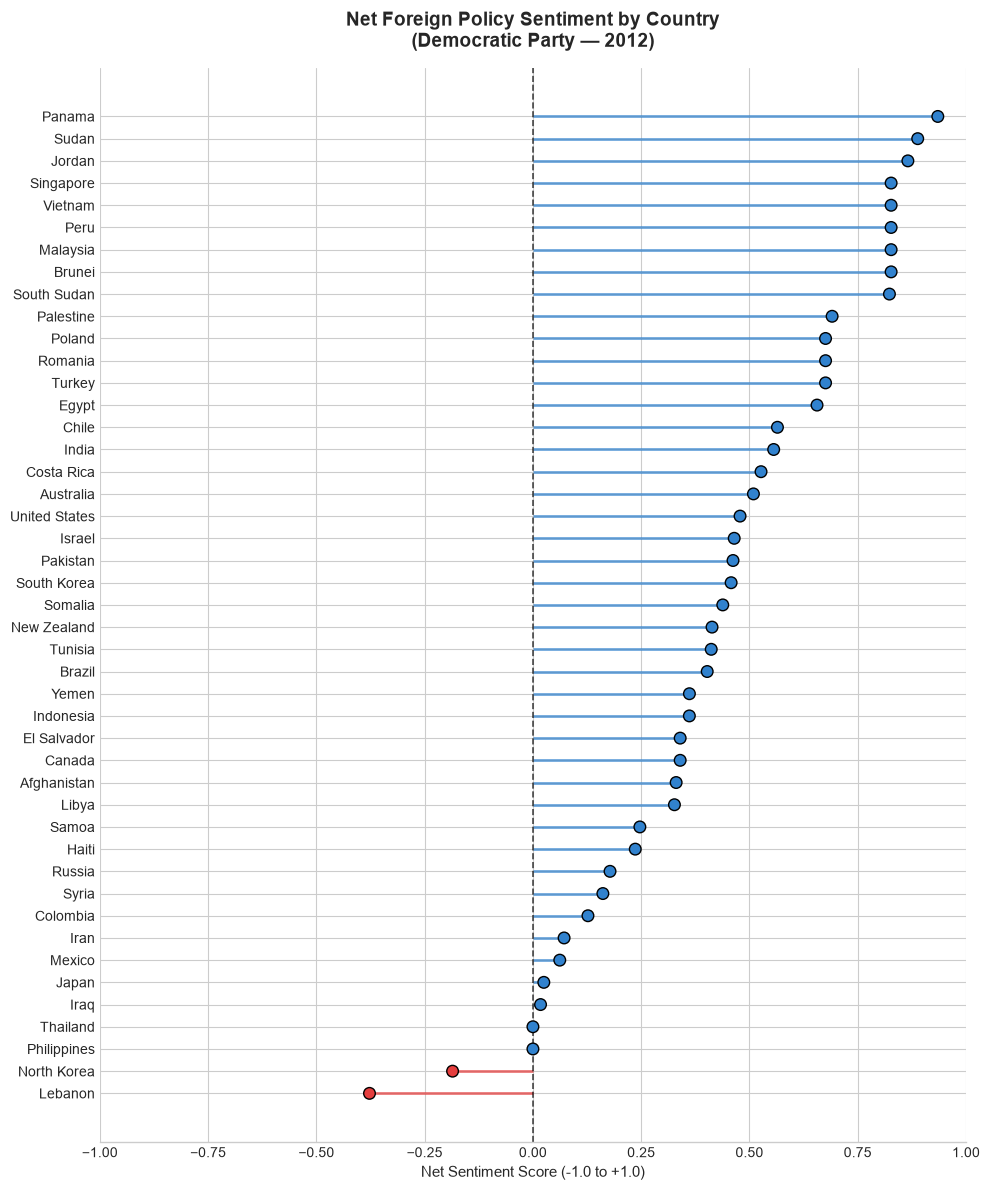

In [8]:
sa.plot_country_sentiment(foreignAffairs_usa, "Democratic Party", 2012, figsize=(10, 12))

In [9]:
foreignAffairs_usa

,year,text,party,sentiment,sentiment_by_countries,number_mentions
0,1960,They have admitted that the Soviet Union leads...,Democratic Party,0.200130,"{'CUBA': -0.0258, 'ISRAEL': 0.60195, 'UNITED_S...","{'CUBA': 1, 'ISRAEL': 2, 'UNITED_STATES': 9}"
1,1964,"In 1960, freedom was on the defensive. The Com...",Democratic Party,0.311839,"{'ALBANIA': 0.9081, 'BULGARIA': 0.9081, 'CENTR...","{'ALBANIA': 1, 'BULGARIA': 1, 'CENTRAL_AFRICAN..."
2,1968,THE WORLD The conscience of the entire world h...,Democratic Party,0.252428,"{'CUBA': 0.25, 'CYPRUS': 0.128, 'INDIA': 0.274...","{'CUBA': 1, 'CYPRUS': 1, 'INDIA': 2, 'INDONESI..."
3,1972,Puerto Rico. The Democratic Party respects and...,Democratic Party,0.043207,"{'BANGLADESH': 0.4252666666666667, 'CAMBODIA':...","{'BANGLADESH': 3, 'CAMBODIA': 1, 'CANADA': 1, ..."
4,1976,And its efforts to preserve rather than reform...,Democratic Party,0.184470,"{'ANGOLA': 0.26853333333333335, 'CANADA': 0.29...","{'ANGOLA': 3, 'CANADA': 1, 'CHILE': 1, 'CUBA':..."
5,1980,We know only too well the dangers and sacrific...,Democratic Party,0.277482,"{'AFGHANISTAN': 0.057760000000000006, 'ANGOLA'...","{'AFGHANISTAN': 15, 'ANGOLA': 1, 'ARGENTINA': ..."
6,1984,The President who destroyed the Environmental ...,Democratic Party,0.112573,"{'AFGHANISTAN': 0.047550000000000016, 'ARGENTI...","{'AFGHANISTAN': 6, 'ARGENTINA': 1, 'AUSTRALIA'..."
7,1988,We believe that with these changes the country...,Democratic Party,0.564485,"{'ANGOLA': -0.3843, 'CYPRUS': 0.981, 'HONDURAS...","{'ANGOLA': 2, 'CYPRUS': 1, 'HONDURAS': 1, 'IRA..."
8,1992,Defense Conversion. Our economy needs both the...,Democratic Party,0.262715,"{'BOSNIA': 0.0516, 'CUBA': 0.875, 'CYPRUS': 0....","{'BOSNIA': 1, 'CUBA': 1, 'CYPRUS': 2, 'GREECE'..."
9,1996,We recognize the existing status of the Common...,Democratic Party,0.227099,"{'BELARUS': -0.4588, 'BOSNIA': 0.7577, 'COLOMB...","{'BELARUS': 1, 'BOSNIA': 5, 'COLOMBIA': 1, 'CU..."


In [10]:
target_country = "AUSTRALIA"
australia_scores_from_usa = sa.get_country_sentiment(foreignAffairs_usa, country=target_country)
australia_num_mentions_from_usa = sa.get_country_mentions(foreignAffairs_usa, country=target_country)

In [11]:
australia_scores_from_usa

{1960: nan,
 1964: nan,
 1968: nan,
 1972: 0.3182,
 1976: -0.1546,
 1980: 0.4019,
 1984: 0.34,
 1988: 0.5859,
 1992: nan,
 1996: nan,
 2000: 0.23893333333333336,
 2004: 0.20534444444444444,
 2008: 0.9423,
 2012: 0.47476666666666667,
 2016: 0.0,
 2020: 0.4521,
 2024: 0.86715}

In [12]:
australia_num_mentions_from_usa

{1960: 0.0,
 1964: 0.0,
 1968: 0.0,
 1972: 1.0,
 1976: 1.0,
 1980: 1.0,
 1984: 1.0,
 1988: 1.0,
 1992: 0.0,
 1996: 0.0,
 2000: 4.0,
 2004: 9.0,
 2008: 1.0,
 2012: 4.0,
 2016: 2.0,
 2020: 2.0,
 2024: 2.0}

## 4. Australia manifesto analysis

The same procedure is applied to Australian manifestos.

The `Foreign_Affairs` corpus generated during the topic-analysis stage is loaded and passed through the sentiment-analysis pipeline.

Country mentions are then identified and aggregated to obtain country-specific sentiment scores.

This makes it possible, for example, to study how the **United States** is discussed by Australian political parties.

In [13]:
aus_foreignAffairs = pd.read_csv("../data/intermediate/foreign_affairs/australia_foreignAffairs_text.csv", index_col=0)
aus_foreignAffairs = sa.compute_sentiment(aus_foreignAffairs)

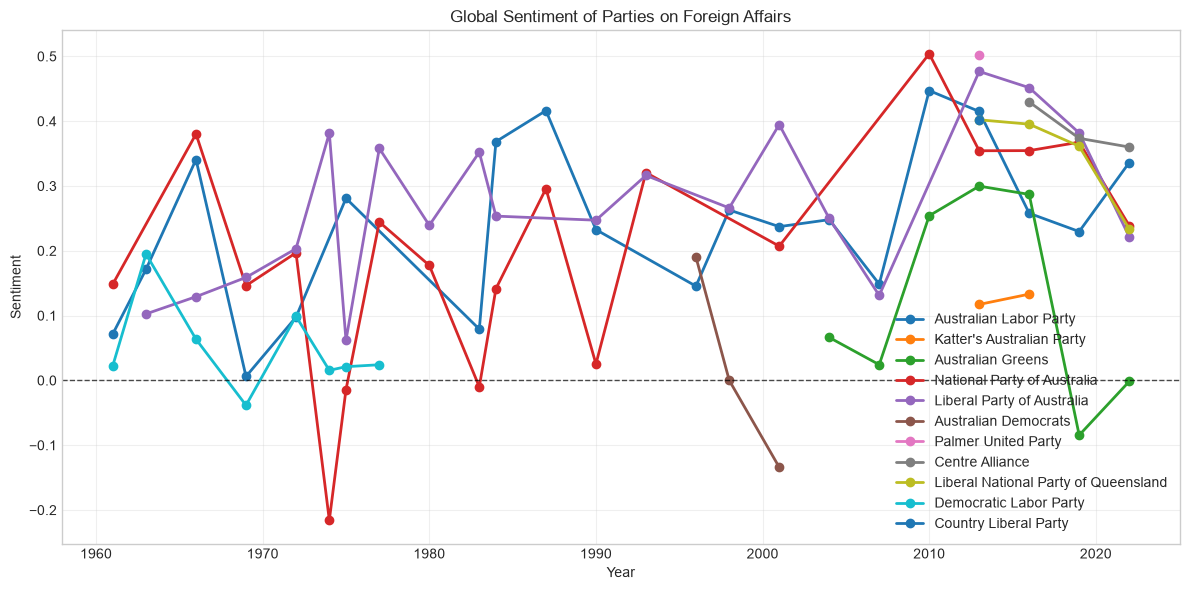

In [14]:
sa.plot_sentiment(aus_foreignAffairs)

In [15]:
foreignAffairs_aus = sa.compute_country_scores(
    section_dataframe=aus_foreignAffairs, 
    nlp=NLP, 
    analyzer=sentiment_analyzer, 
    country_synonyms_dict=COUNTRY_SYNONYMS_DICT
)

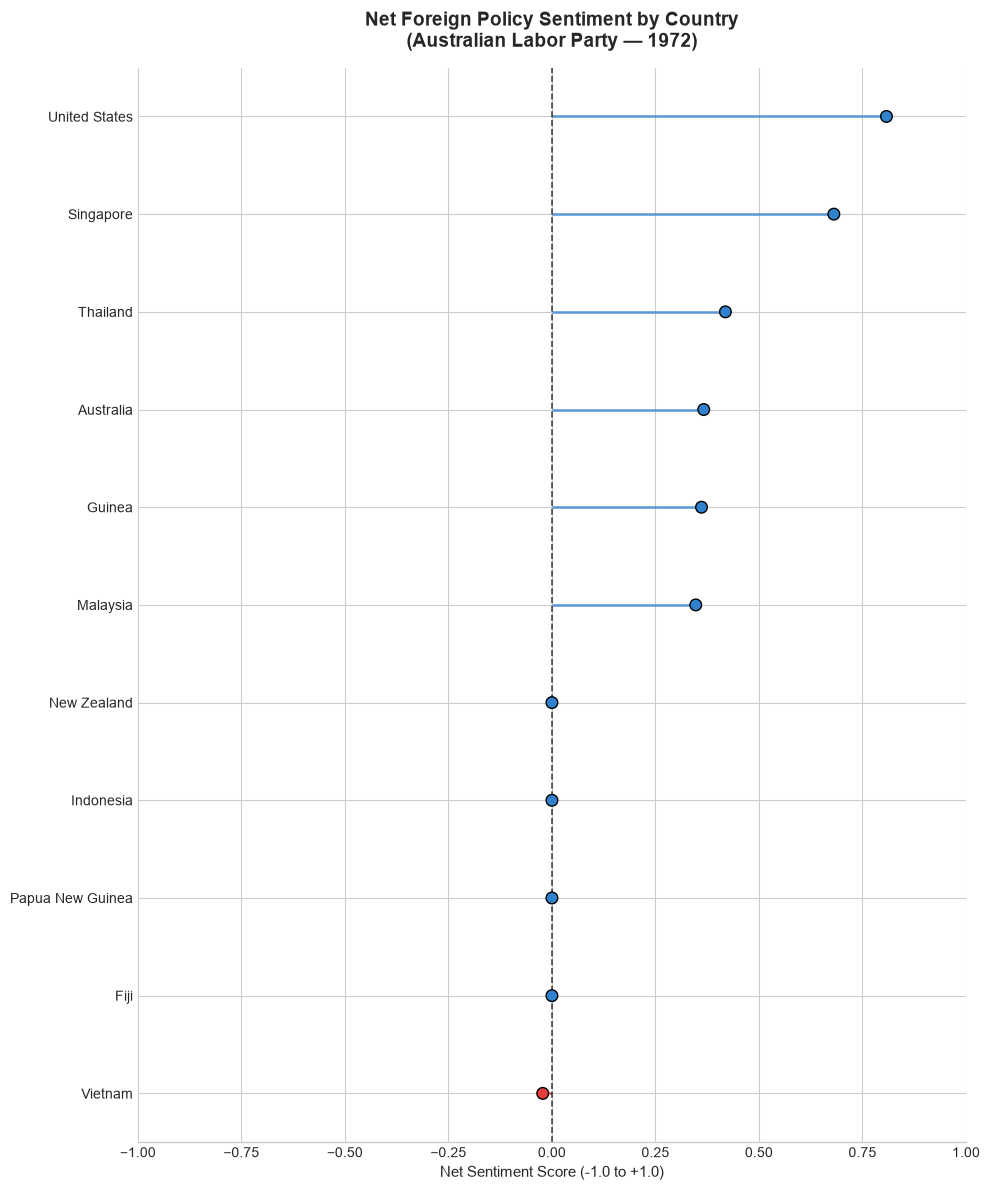

In [16]:
sa.plot_country_sentiment(foreignAffairs_aus, "Australian Labor Party", 1972, figsize=(10, 12))

In [26]:
target_country = "UNITED_STATES"
usa_scores_from_australia = sa.get_country_sentiment(foreignAffairs_aus, country=target_country)

In [ ]:
usa_scores_from_australia
# Pour utiliser ces valeurs dans UN_Voting, après la copie, il faut remplacer les nan par None.

{1961: -0.5423,
 1963: 0.6031888888888889,
 1966: 0.4222821428571429,
 1969: 0.2819666666666667,
 1972: 0.61315,
 1974: 0.49305000000000004,
 1975: 0.6597,
 1977: 0.6611750000000001,
 1980: 0.28552857142857146,
 1983: 0.55865,
 1984: 0.26955,
 1987: 0.819475,
 1990: 0.307525,
 1993: nan,
 1996: 0.5122857142857143,
 1998: nan,
 2001: -0.18579999999999997,
 2004: 0.560075,
 2007: 0.40775,
 2010: 0.08708333333333329,
 2013: 0.4957833333333333,
 2016: 0.7609999999999999,
 2019: 0.19785694444444443,
 2022: 0.36210213675213676}

## 5. Interpretation

The final outputs of this notebook are country-level sentiment scores associated with a political party and an election year.

These scores constitute the final analytical data used to compare the treatment of foreign countries across parties, elections and countries.

The interpretation should therefore consider both:

* **topic selection**, which determines which sentences enter the analysis;
* **sentiment scoring**, which determines the tone associated with the countries mentioned in those sentences.

The sentiment analysis should consequently be understood as the second stage of the broader pipeline rather than as an independent analysis.